# Gridworld Task: Model Comparison
Run `python GridworldPE.py` first to generate `./data/gridworld/results.npz`.

## 0  Imports and data loading

In [152]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.ndimage import uniform_filter1d

matplotlib.rcParams.update({'font.size':10,'axes.titlesize':11,'axes.labelsize':10,
    'xtick.labelsize':9,'ytick.labelsize':9,'figure.dpi':120,
    'axes.spines.top':False,'axes.spines.right':False})

COLORS={'ScalarRPE':'#1f77b4','OutcomePE':'#d62728','VectorRPE':'#2ca02c',
        'VectorAPE':'#9467bd','TimescaleRPE':'#ff7f0e'}
MODEL_NAMES=['ScalarRPE','OutcomePE','VectorRPE','VectorAPE','TimescaleRPE']
smooth=lambda x,w=15: uniform_filter1d(x.astype(float),size=w)

In [153]:
# Load all data into a private dict _D so the arr() closure
# is immune to any later cell rebinding the name 'd'.
_D = dict(np.load('./data/gridworld/results.npz', allow_pickle=True))
def arr(k): return _D[k]

H,W=int(_D['H']),int(_D['W'])
N_FEATURES=int(_D['N_FEATURES'])
N_OUT_CH=int(_D['N_OUT_CH'])
N_VALUES=int(_D['N_VALUES'])
EPB=int(_D['EPS_PER_BLOCK'])
N_BLOCKS=int(_D['N_BLOCKS'])
FEATURE_MODE=str(_D['FEATURE_MODE'])
block_goals=np.atleast_2d(_D['block_goals']); block_eps=np.atleast_1d(_D['block_eps']).tolist()  # 0-d-safe conversion to Python list
checkpoints=_D['checkpoints']; PHI=_D['phi_all']
feat_centres=_D['feat_centres'] if _D['feat_centres'].shape[0]>0 else None
TOTAL_EPS=EPB*N_BLOCKS

print(f'Grid {H}x{W} | blocks={N_BLOCKS} | eps/block={EPB}')
print(f'N_FEATURES={N_FEATURES} (mode={FEATURE_MODE!r})  N_VALUES={N_VALUES}')
print(f'Block goals: {[g for g in block_goals]}')
unique_goals=[(int(g[0]),int(g[1])) for g in dict.fromkeys(map(tuple,block_goals))]
print(f'Unique goals ({len(unique_goals)}): {unique_goals}')


Grid 7x7 | blocks=32 | eps/block=50
N_FEATURES=16 (mode='rbf_coarse')  N_VALUES=4
Block goals: [array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1]), array([1, 1]), array([5, 5]), array([1, 5]), array([5, 1])]
Unique goals (4): [(1, 1), (5, 5), (1, 5), (5, 1)]


## 1  Task visualisation

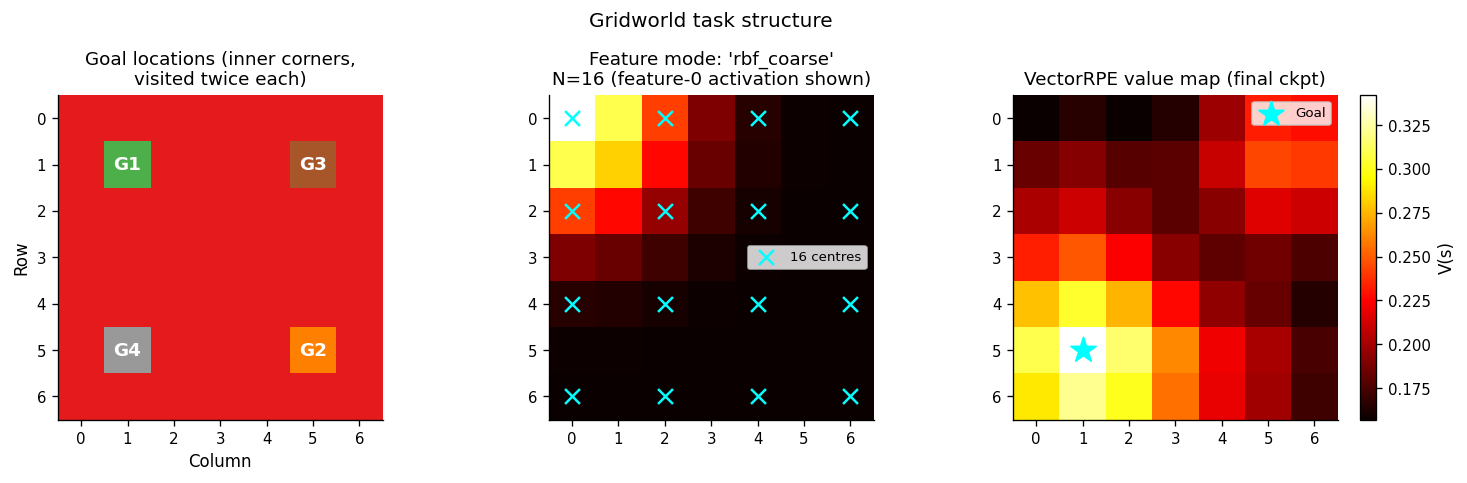

In [154]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
fig.suptitle('Gridworld task structure',fontsize=12)

ax=axes[0]
grid_img=np.zeros((H,W))
for blk,(gr,gc) in enumerate(block_goals[:4]): grid_img[gr,gc]=blk+1
ax.imshow(grid_img,cmap='Set1',vmin=0,vmax=4,origin='upper')
for blk,(gr,gc) in enumerate(block_goals[:4]):
    ax.text(gc,gr,f'G{blk+1}',ha='center',va='center',fontweight='bold',fontsize=11,color='white')
ax.set_title('Goal locations (inner corners,\nvisited twice each)')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(range(W)); ax.set_yticks(range(H))

ax=axes[1]
ax.imshow(PHI[:,0].reshape(H,W),cmap='hot',origin='upper')
if feat_centres is not None:
    ax.scatter(feat_centres[:,1],feat_centres[:,0],c='cyan',s=80,marker='x',linewidths=1.5,label=f'{N_FEATURES} centres')
    ax.legend(fontsize=8)
ax.set_title(f'Feature mode: {FEATURE_MODE!r}\nN={N_FEATURES} (feature-0 activation shown)')
ax.set_xticks(range(W)); ax.set_yticks(range(H))

ax=axes[2]
vmap=arr('VectorRPE__val_maps')[-1]
gr,gc=block_goals[-1]
im=ax.imshow(vmap,cmap='hot',origin='upper')
ax.scatter([gc],[gr],marker='*',s=250,c='cyan',zorder=5,label='Goal')
plt.colorbar(im,ax=ax,label='V(s)'); ax.set_title('VectorRPE value map (final ckpt)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig1_task.pdf',bbox_inches='tight'); plt.show()

## 2  Learning curves

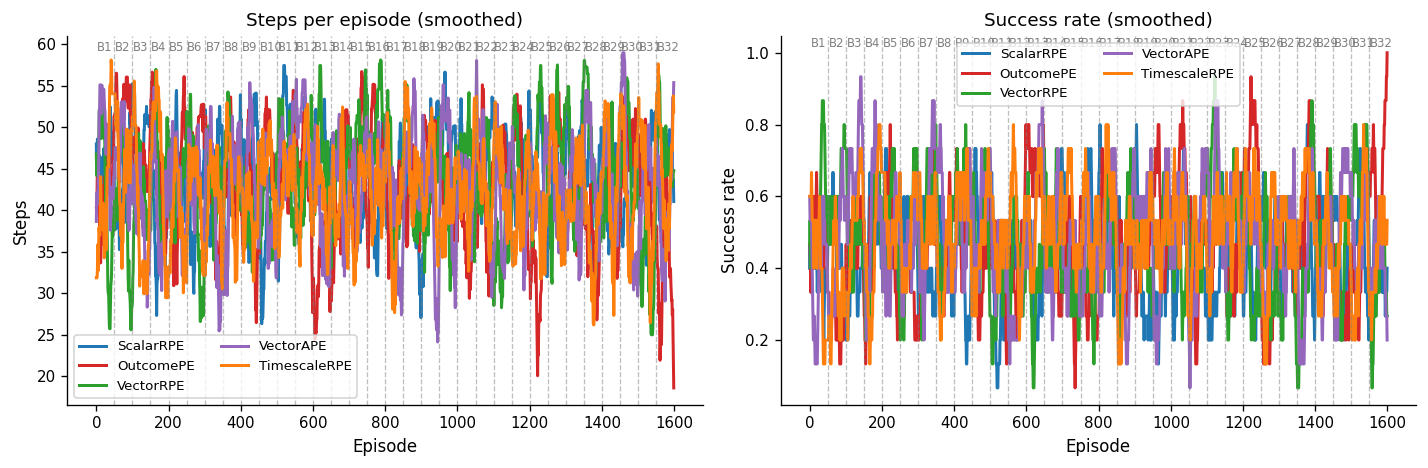

In [155]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name in MODEL_NAMES:
    axes[0].plot(smooth(np.asarray(arr(f'{name}__steps')).ravel()),color=COLORS[name],label=name,lw=1.8)
    axes[1].plot(smooth(np.asarray(arr(f'{name}__success')).ravel()),color=COLORS[name],label=name,lw=1.8)
for ax in axes:
    for be in block_eps[1:]: ax.axvline(be,color='gray',lw=0.8,ls='--',alpha=0.5)
    for i,be in enumerate(block_eps): ax.text(be+2,ax.get_ylim()[1]*0.97,f'B{i+1}',fontsize=7,color='gray')
    ax.set_xlabel('Episode'); ax.legend(fontsize=8,ncol=2)
axes[0].set_ylabel('Steps'); axes[0].set_title('Steps per episode (smoothed)')
axes[1].set_ylabel('Success rate'); axes[1].set_title('Success rate (smoothed)')
plt.tight_layout(); plt.savefig('./data/gridworld/fig2_learning.pdf',bbox_inches='tight'); plt.show()

## 3  TD loss

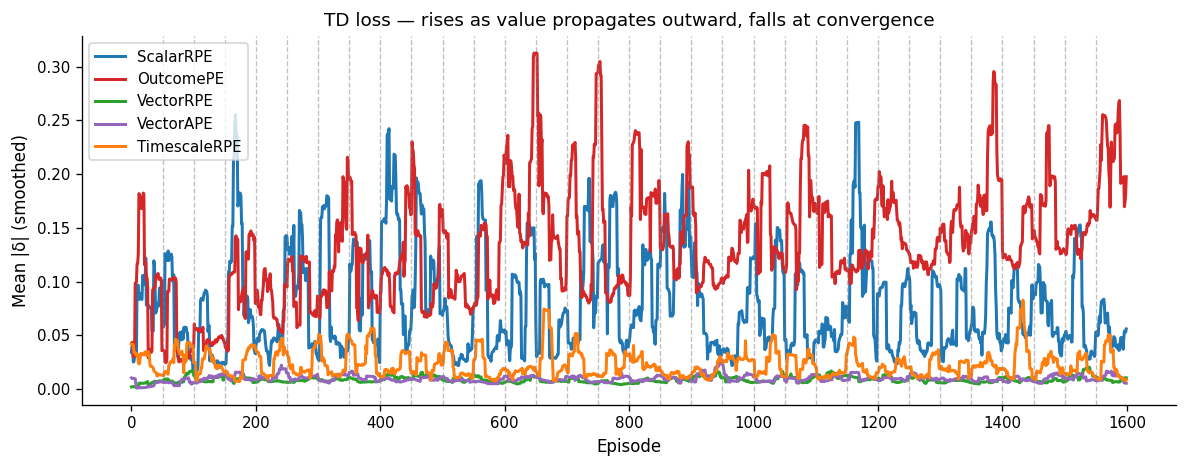

In [156]:
fig,ax=plt.subplots(figsize=(10,4))
for name in MODEL_NAMES:
    ax.plot(smooth(np.asarray(arr(f'{name}__td_loss')).ravel()),color=COLORS[name],label=name,lw=1.8)
for be in block_eps[1:]: ax.axvline(be,color='gray',lw=0.8,ls='--',alpha=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean |δ| (smoothed)')
ax.set_title('TD loss — rises as value propagates outward, falls at convergence')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('./data/gridworld/fig3_td_loss.pdf',bbox_inches='tight'); plt.show()

## 4  Value map evolution

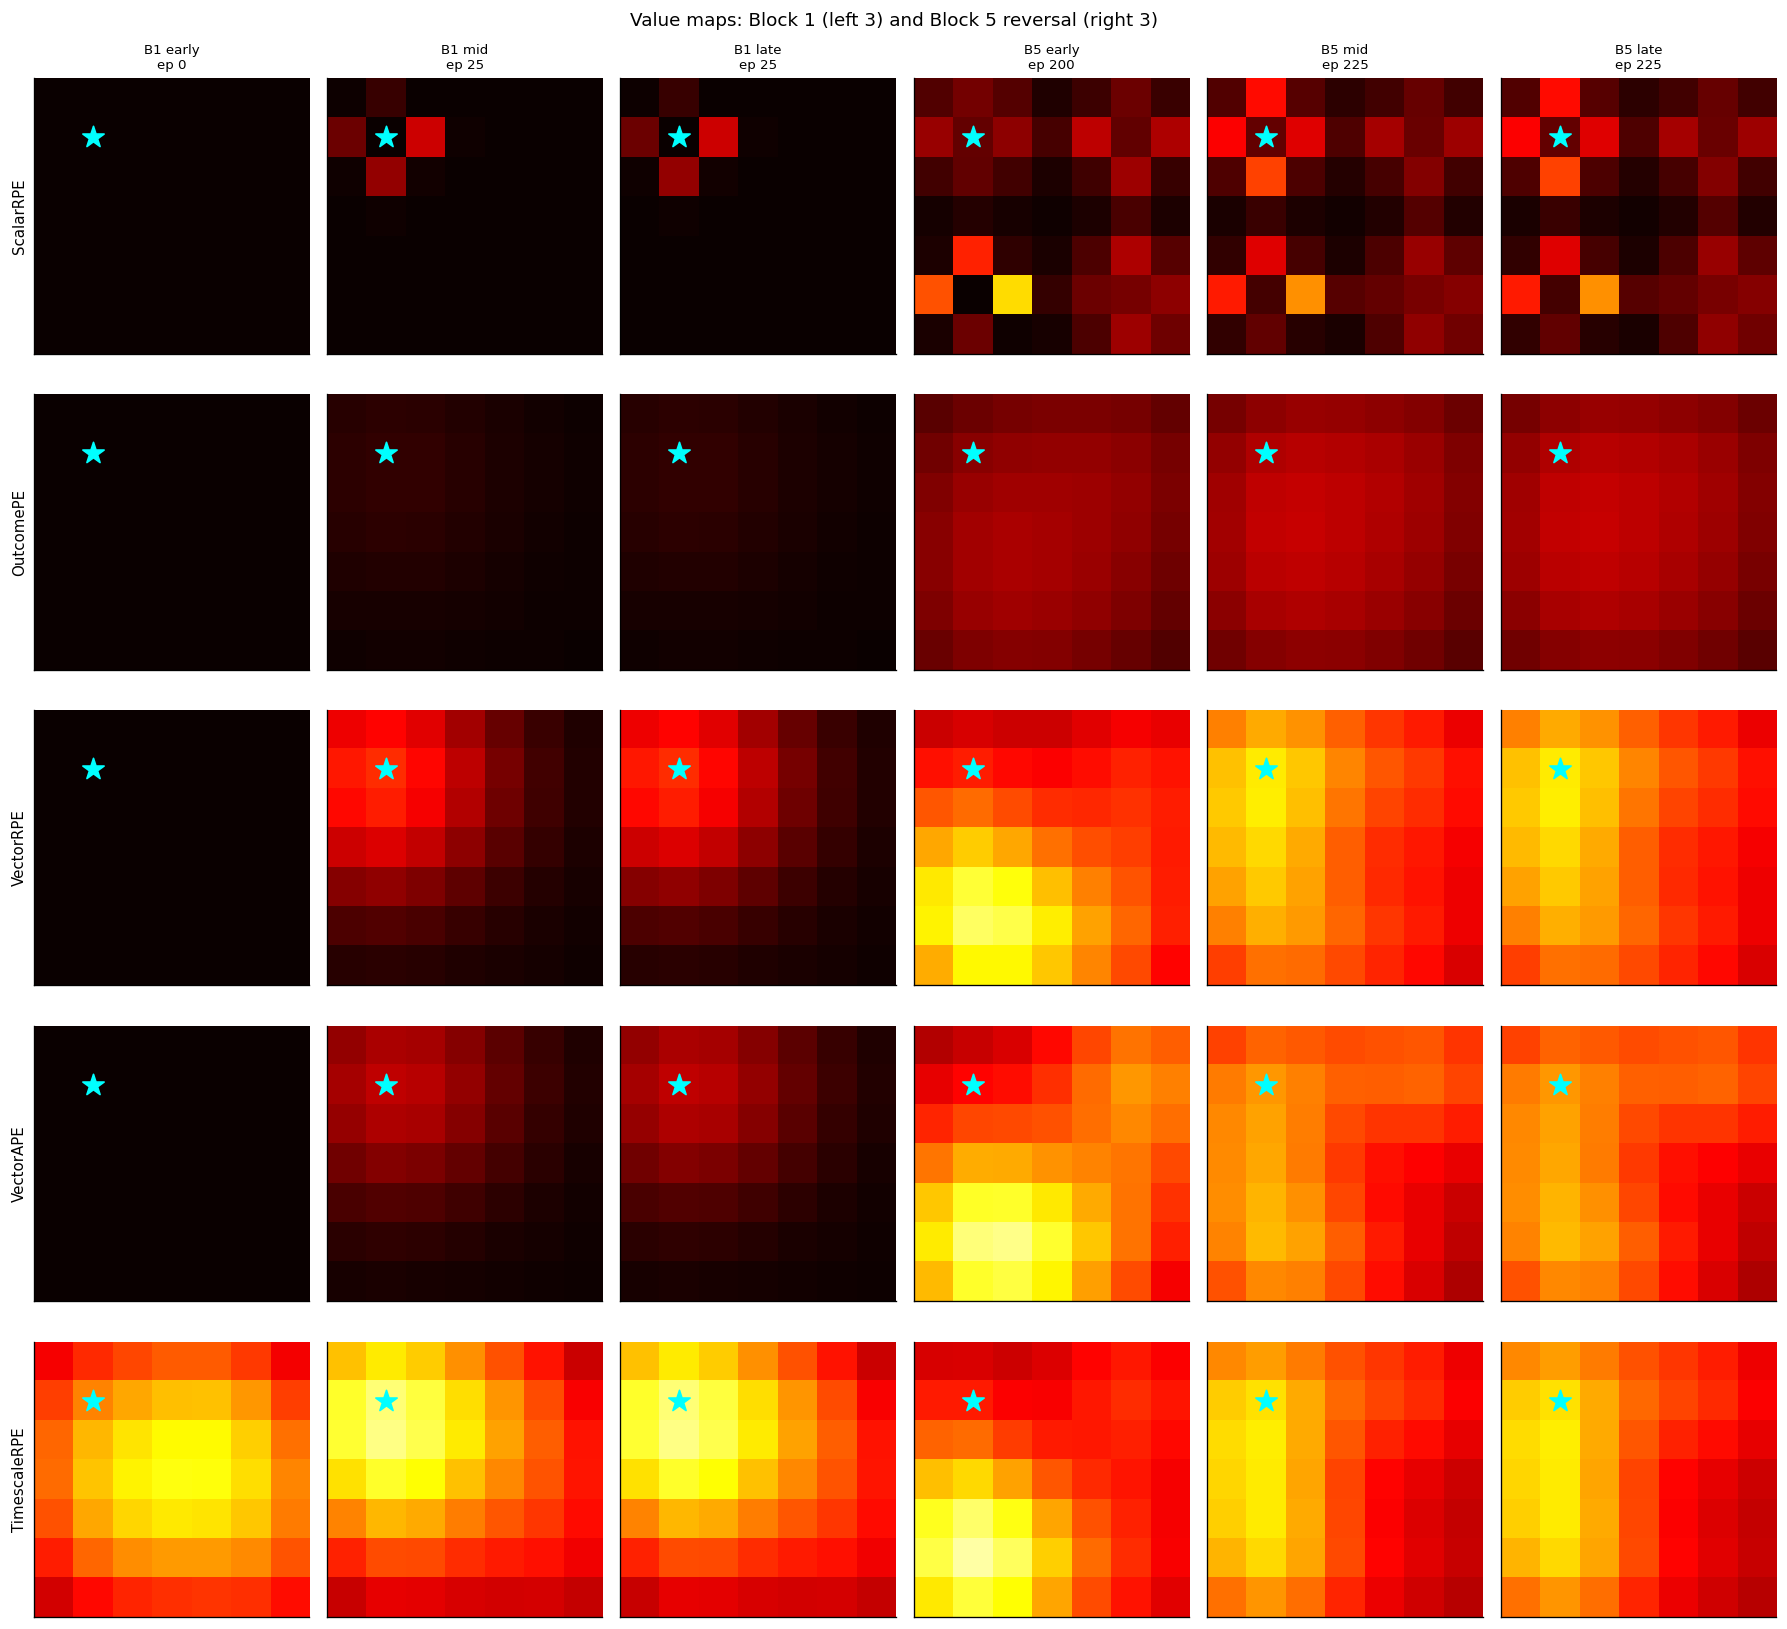

In [157]:
def ckpts_in_block(blk):
    s,e=blk*EPB,(blk+1)*EPB
    idx=np.where((checkpoints>=s)&(checkpoints<e))[0]
    return idx[[0,len(idx)//2,-1]]

b1=ckpts_in_block(0); b5=ckpts_in_block(4)
fig,axes=plt.subplots(len(MODEL_NAMES),6,figsize=(15,2.8*len(MODEL_NAMES)))
fig.suptitle('Value maps: Block 1 (left 3) and Block 5 reversal (right 3)',fontsize=11)
for row,name in enumerate(MODEL_NAMES):
    vmaps=arr(f'{name}__val_maps'); vmax=np.percentile(vmaps,98)
    for col,(ci,bi,lbl) in enumerate([(b1[0],0,'B1 early'),(b1[1],0,'B1 mid'),(b1[2],0,'B1 late'),
                                       (b5[0],4,'B5 early'),(b5[1],4,'B5 mid'),(b5[2],4,'B5 late')]):
        ax=axes[row,col]; gr,gc=block_goals[bi]
        im=ax.imshow(vmaps[ci],cmap='hot',origin='upper',vmin=0,vmax=vmax)
        ax.scatter([gc],[gr],marker='*',s=180,c='cyan',zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if col==0: ax.set_ylabel(name,fontsize=9)
        if row==0: ax.set_title(f'{lbl}\nep {checkpoints[ci]}',fontsize=8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig4_value_maps.pdf',bbox_inches='tight'); plt.show()

## 5  DA signal maps

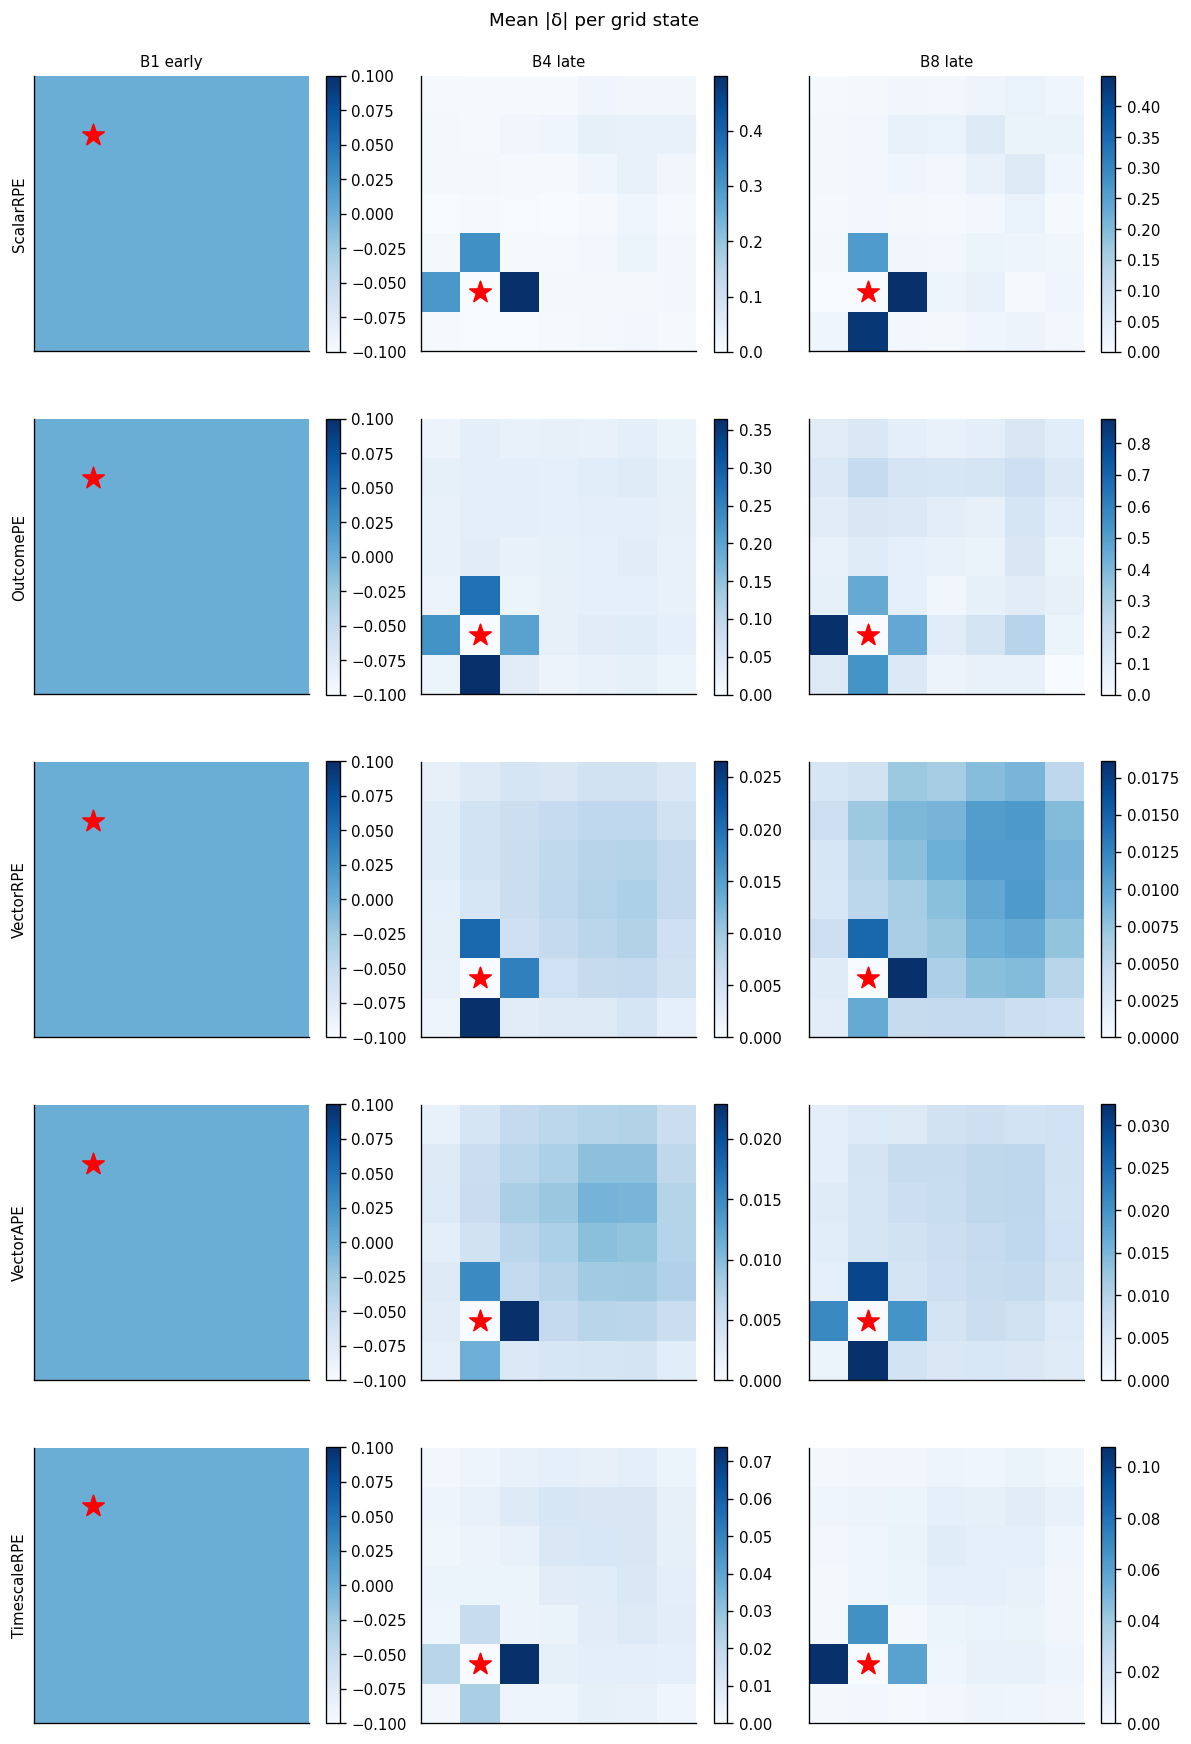

In [158]:
fb=ckpts_in_block(N_BLOCKS-1)
three=[ b1[0], ckpts_in_block(3)[-1], fb[-1] ]
lbls=['B1 early','B4 late','B8 late']; bidxs=[0,3,7]
fig,axes=plt.subplots(len(MODEL_NAMES),3,figsize=(10,3*len(MODEL_NAMES)))
fig.suptitle('Mean |δ| per grid state',fontsize=11)
for row,name in enumerate(MODEL_NAMES):
    dmaps=arr(f'{name}__da_maps')
    for col,(ci,lbl,bi) in enumerate(zip(three,lbls,bidxs)):
        ax=axes[row,col]; gr,gc=block_goals[bi]
        im=ax.imshow(dmaps[ci],cmap='Blues',origin='upper')
        ax.scatter([gc],[gr],marker='*',s=180,c='red',zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if col==0: ax.set_ylabel(name,fontsize=9)
        if row==0: ax.set_title(lbl,fontsize=9)
        plt.colorbar(im,ax=ax,shrink=0.8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig5_da_maps.pdf',bbox_inches='tight'); plt.show()

## 6  OutcomePE: per-channel (τ) value maps

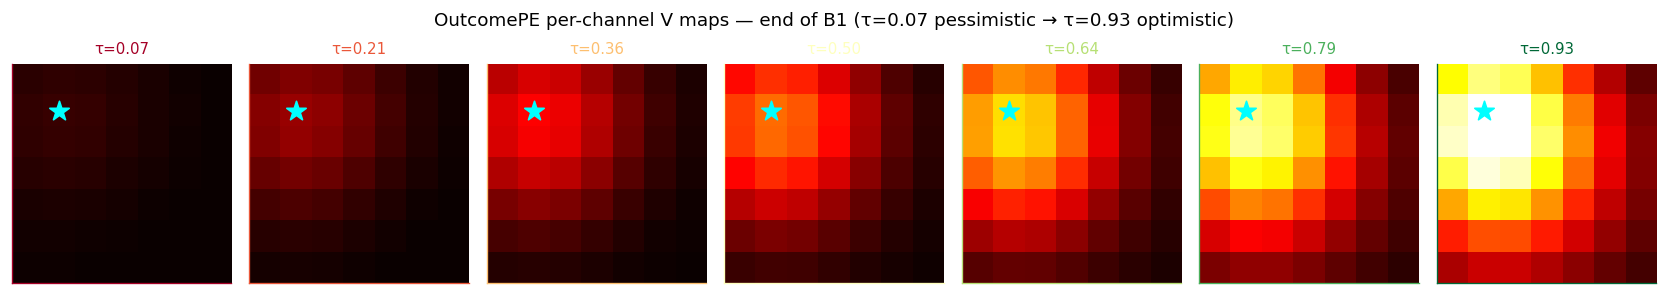

In [159]:
taus=np.array([(2*i-1)/(2*N_OUT_CH) for i in range(1,N_OUT_CH+1)])
cmaps=arr('OutcomePE__chan_val_maps'); ci_late=ckpts_in_block(0)[-1]
gr,gc=block_goals[0]
fig,axes=plt.subplots(1,N_OUT_CH,figsize=(14,2.5))
fig.suptitle('OutcomePE per-channel V maps — end of B1 (τ=0.07 pessimistic → τ=0.93 optimistic)',fontsize=11)
cmap_t=plt.cm.RdYlGn; vmax=np.percentile(np.abs(cmaps[ci_late]),99)
for ch in range(N_OUT_CH):
    ax=axes[ch]
    ax.imshow(cmaps[ci_late,ch],cmap='hot',origin='upper',vmin=0,vmax=vmax)
    ax.scatter([gc],[gr],marker='*',s=150,c='cyan',zorder=5)
    ax.set_xticks([]); ax.set_yticks([])
    col=cmap_t(ch/(N_OUT_CH-1))
    ax.set_title(f'τ={taus[ch]:.2f}',fontsize=9,color=col)
    for sp in ax.spines.values(): sp.set_color(col)
plt.tight_layout(); plt.savefig('./data/gridworld/fig6_outcome_channels.pdf',bbox_inches='tight'); plt.show()

## 7  TimescaleRPE: per-channel value maps  V_i(s)

TimescaleRPE has **N_VALUES** independent value channels.  Each channel i learns
a full weight vector  w_i ∈ ℝ^J  and computes  V_i(s) = w_i · φ(s).  
The spatial map of  V_i  shows which part of the grid that channel is most
associated with.  The β_i bar chart shows the learned channel gains.

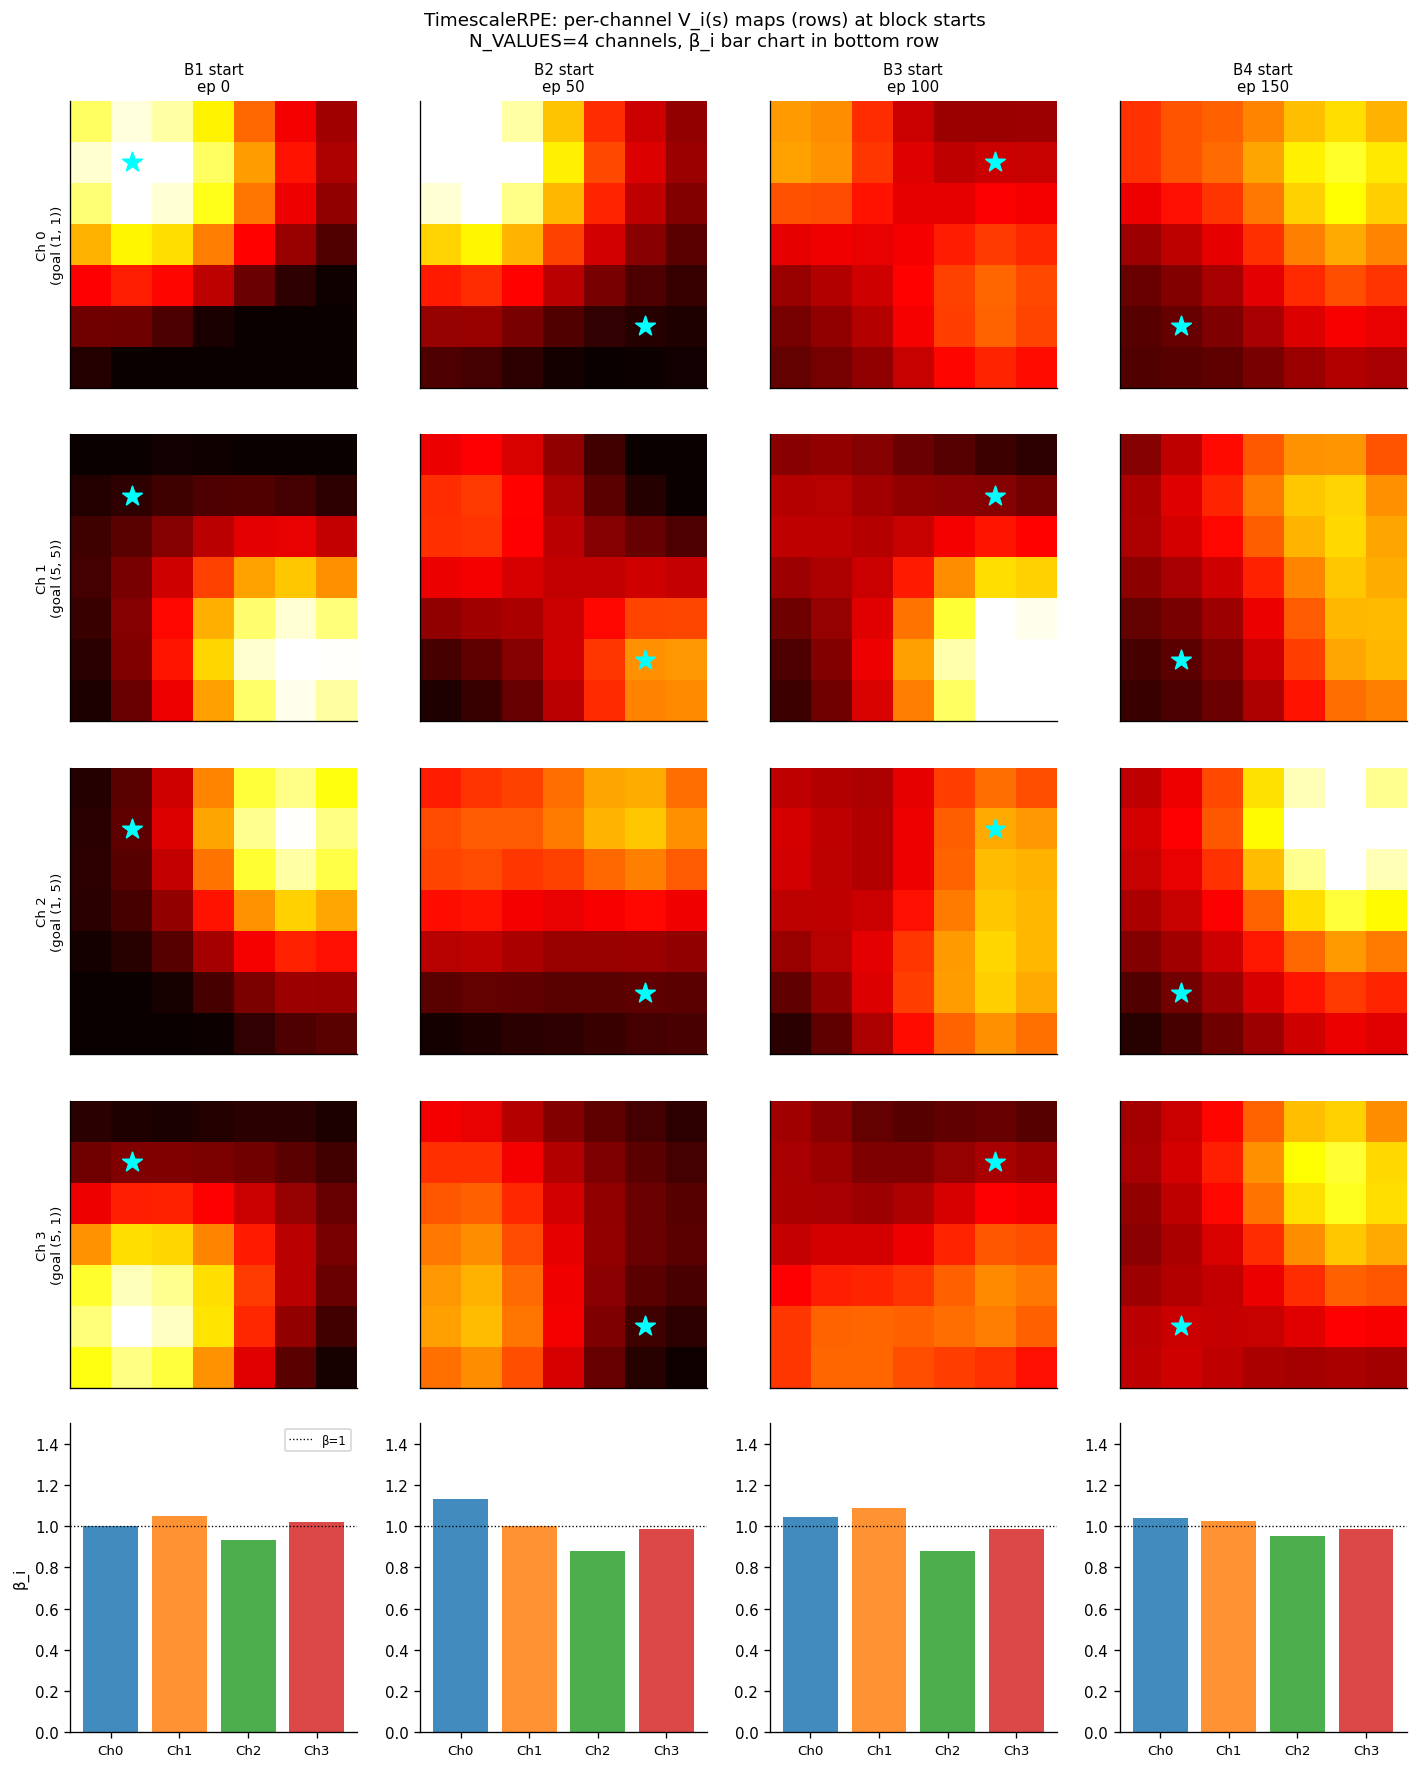

In [160]:
chan_vmaps=arr('TimescaleRPE__chan_val_maps')  # (N_ckpts, N_VALUES, H, W)
beta_hist =arr('TimescaleRPE__beta_history')   # (N_ckpts, N_VALUES)
goal_labels=[f'Goal {g}' for g in unique_goals]

# Show 4 checkpoints: start of each of the first 4 blocks
ckpt_per_blk=[ckpts_in_block(b)[0] for b in range(min(4,N_BLOCKS))]

fig,axes=plt.subplots(N_VALUES+1, len(ckpt_per_blk), figsize=(3*len(ckpt_per_blk), 3*(N_VALUES+1)))
fig.suptitle(f'TimescaleRPE: per-channel V_i(s) maps (rows) at block starts\n'
             f'N_VALUES={N_VALUES} channels, β_i bar chart in bottom row',fontsize=11)

for col,ci in enumerate(ckpt_per_blk):
    blk=col; gr,gc=block_goals[blk]
    vmax=np.percentile(chan_vmaps[ci],98)
    # Per-channel value maps
    for ch in range(N_VALUES):
        ax=axes[ch,col]
        im=ax.imshow(chan_vmaps[ci,ch],cmap='hot',origin='upper',vmin=0,vmax=vmax)
        ax.scatter([gc],[gr],marker='*',s=150,c='cyan',zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if col==0: ax.set_ylabel(f'Ch {ch}\n(goal {unique_goals[ch]})',fontsize=8)
        if ch==0: ax.set_title(f'B{blk+1} start\nep {checkpoints[ci]}',fontsize=9)
    # β bar chart
    ax=axes[N_VALUES,col]
    bvals=beta_hist[ci]
    ax.bar(range(N_VALUES),bvals,color=[f'C{c}' for c in range(N_VALUES)],alpha=0.85)
    ax.axhline(1.0,color='k',lw=0.8,ls=':',label='β=1')
    ax.set_xticks(range(N_VALUES))
    ax.set_xticklabels([f'Ch{c}' for c in range(N_VALUES)],fontsize=8)
    ax.set_ylim(0,max(bvals.max()*1.2,1.5))
    if col==0: ax.set_ylabel('β_i',fontsize=9)
    if col==0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('./data/gridworld/fig7_timescale_channels.pdf',bbox_inches='tight')
plt.show()

## 7b  TimescaleRPE: β dynamics over full training

Each of the N_VALUES channel gains β_i is plotted over all episodes.
A rising β_i means that channel is becoming increasingly weighted in V_tot.
Block boundaries are marked with dashed lines.

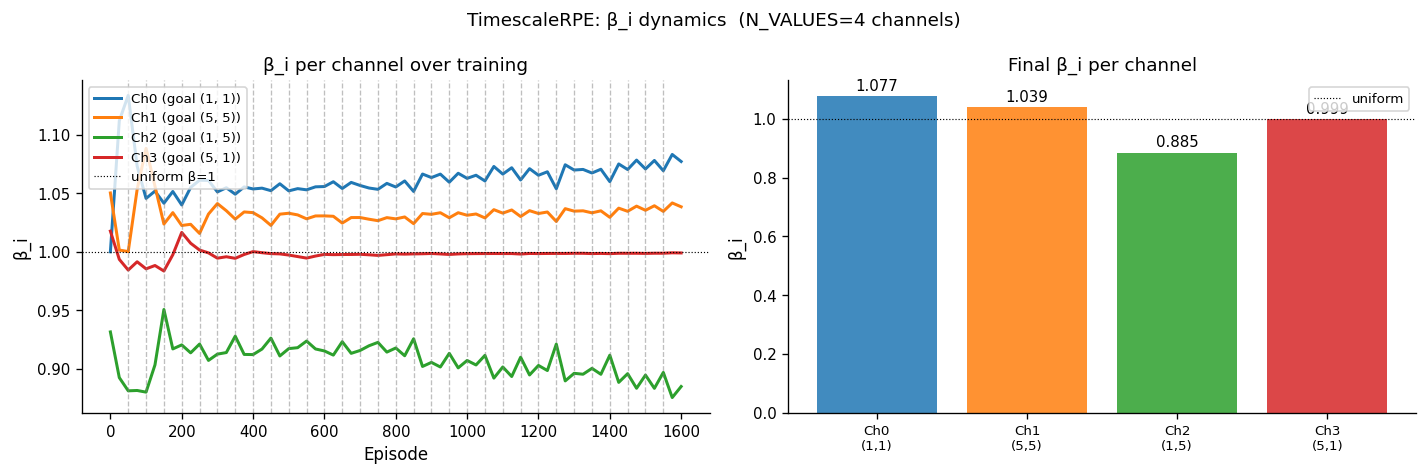

In [161]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle(f'TimescaleRPE: β_i dynamics  (N_VALUES={N_VALUES} channels)',fontsize=11)

# Left: trajectory
ax=axes[0]
for ch in range(N_VALUES):
    ax.plot(checkpoints,beta_hist[:,ch],color=f'C{ch}',lw=1.8,
            label=f'Ch{ch} (goal {unique_goals[ch]})')
for be in block_eps[1:]: ax.axvline(be,color='gray',lw=0.8,ls='--',alpha=0.5)
ax.axhline(1.0,color='k',lw=0.7,ls=':',label='uniform β=1')
ax.set_xlabel('Episode'); ax.set_ylabel('β_i')
ax.set_title('β_i per channel over training')
ax.legend(fontsize=8)

# Right: final β bar
ax=axes[1]
final_b=beta_hist[-1]
bars=ax.bar(range(N_VALUES),final_b,color=[f'C{c}' for c in range(N_VALUES)],alpha=0.85)
for bar,v in zip(bars,final_b): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.02,f'{v:.3f}',ha='center',fontsize=9)
ax.axhline(1.0,color='k',lw=0.7,ls=':',label='uniform')
ax.set_xticks(range(N_VALUES))
ax.set_xticklabels([f'Ch{c}\n({unique_goals[c][0]},{unique_goals[c][1]})' for c in range(N_VALUES)],fontsize=8)
ax.set_ylabel('β_i'); ax.set_title('Final β_i per channel')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig7b_beta_dynamics.pdf',bbox_inches='tight'); plt.show()

## 8  VectorAPE: directional DA maps

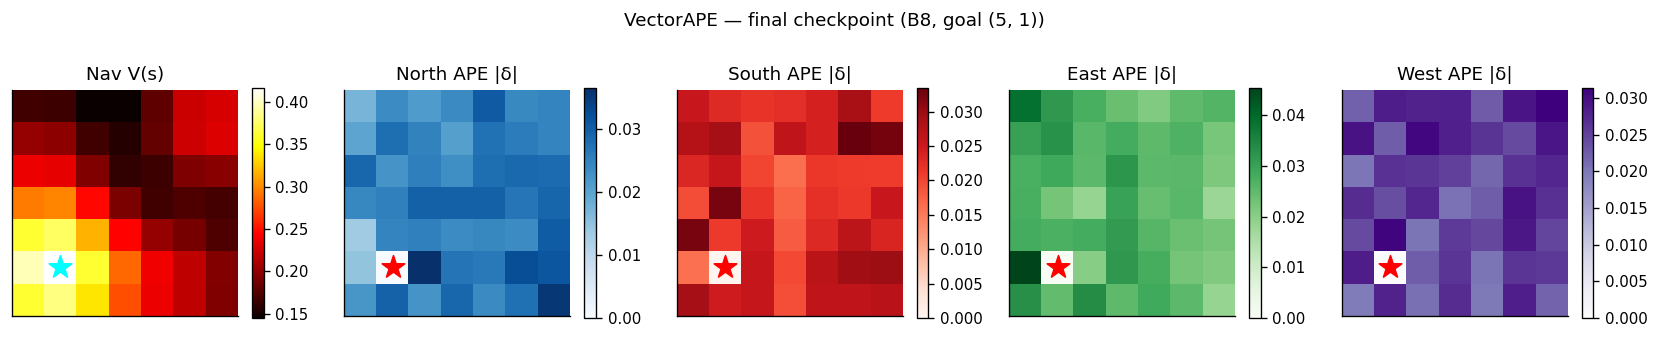

In [162]:
ape_da=arr('VectorAPE__ape_da_maps'); nav_vm=arr('VectorAPE__nav_val_maps')
ci_fin=len(checkpoints)-1; gr,gc=block_goals[-1]
fig,axes=plt.subplots(1,5,figsize=(14,3))
fig.suptitle(f'VectorAPE — final checkpoint (B8, goal {(int(block_goals[-1][0]),int(block_goals[-1][1]))})',fontsize=11)
ax=axes[0]; im=ax.imshow(nav_vm[ci_fin],cmap='hot',origin='upper')
ax.scatter([gc],[gr],marker='*',s=200,c='cyan',zorder=5)
ax.set_title('Nav V(s)'); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im,ax=ax,shrink=0.8)
for d,(dn,dc) in enumerate(zip(['North','South','East','West'],['Blues','Reds','Greens','Purples'])):
    ax=axes[d+1]; im=ax.imshow(ape_da[ci_fin,d],cmap=dc,origin='upper')
    ax.scatter([gc],[gr],marker='*',s=200,c='red',zorder=5)
    ax.set_title(f'{dn} APE |δ|'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im,ax=ax,shrink=0.8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig8_ape_maps.pdf',bbox_inches='tight'); plt.show()

## 9  Block adaptation dynamics

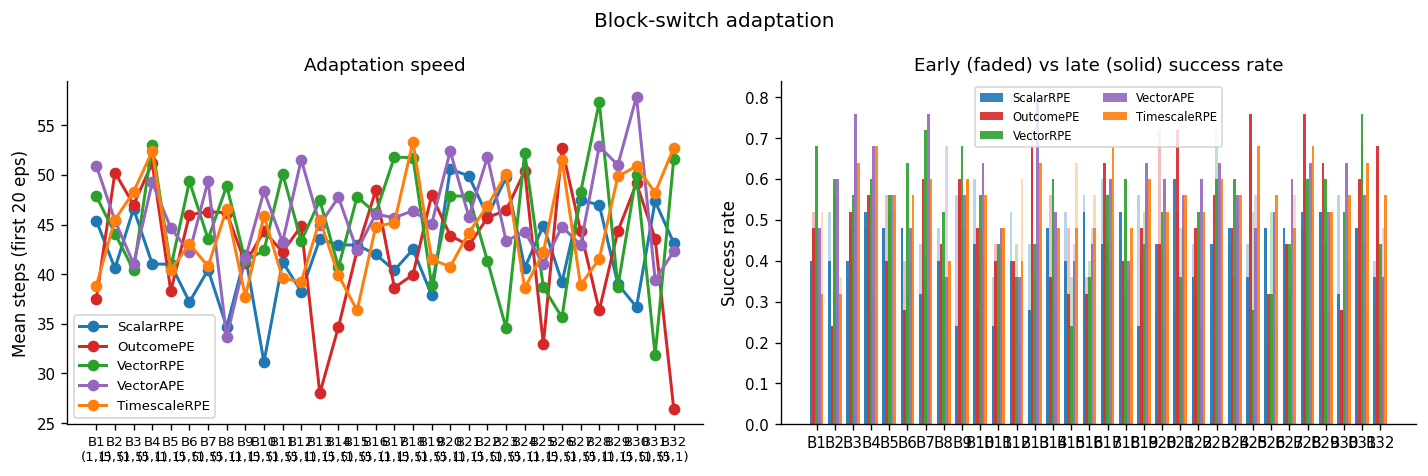

In [163]:
ADAPT=20
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Block-switch adaptation',fontsize=12)
ax=axes[0]
for name in MODEL_NAMES:
    steps=np.asarray(arr(f'{name}__steps')).ravel()
    means=[np.mean(steps[int(block_eps[b]):int(block_eps[b])+ADAPT]) for b in range(N_BLOCKS)]
    ax.plot(range(N_BLOCKS),means,'-o',color=COLORS[name],label=name,lw=1.8,ms=6)
ax.set_xticks(range(N_BLOCKS))
ax.set_xticklabels([f'B{i+1}\n({int(block_goals[i][0])},{int(block_goals[i][1])})' for i in range(N_BLOCKS)],fontsize=8)
ax.set_ylabel(f'Mean steps (first {ADAPT} eps)'); ax.set_title('Adaptation speed')
ax.legend(fontsize=8)

ax=axes[1]; half=EPB//2; x=np.arange(N_BLOCKS); w=0.15
for mi,name in enumerate(MODEL_NAMES):
    succ=np.asarray(arr(f'{name}__success')).ravel()
    early=[np.mean(np.asarray(succ).flat[int(block_eps[b]):int(block_eps[b])+half]) for b in range(N_BLOCKS)]
    late=[np.mean(np.asarray(succ).flat[int(block_eps[b])+half:int(block_eps[b])+EPB]) for b in range(N_BLOCKS)]
    off=(mi-2)*w
    ax.bar(x+off,late,width=w,color=COLORS[name],alpha=0.9,label=name)
    ax.bar(x+off,early,width=w,color=COLORS[name],alpha=0.3)
ax.set_xticks(x); ax.set_xticklabels([f'B{i+1}' for i in range(N_BLOCKS)])
ax.set_ylabel('Success rate'); ax.set_title('Early (faded) vs late (solid) success rate')
ax.legend(fontsize=7,ncol=2)
plt.tight_layout(); plt.savefig('./data/gridworld/fig9_adaptation.pdf',bbox_inches='tight'); plt.show()

## 10  Model comparison summary

/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_55158/190320356.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES,rotation=20,ha='right')
/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_55158/190320356.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES,rotation=20,ha='right')
/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_55158/190320356.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES,rotation=20,ha='right')


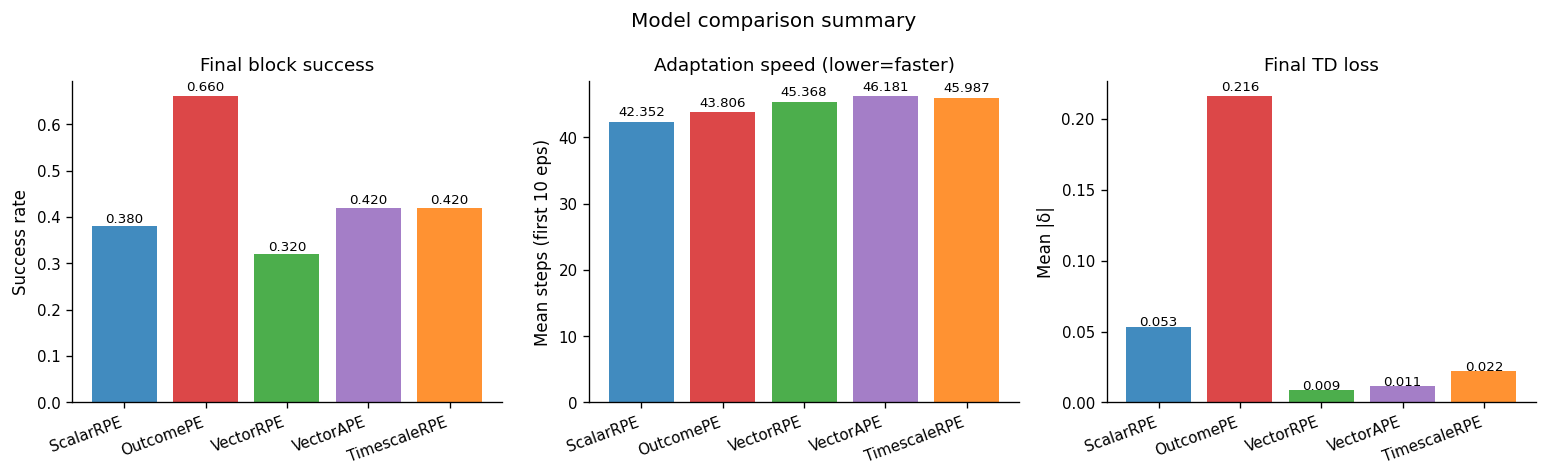

In [164]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
fig.suptitle('Model comparison summary',fontsize=12)
final_succ=[np.mean(np.asarray(arr(f'{n}__success')).ravel()[-EPB:]) for n in MODEL_NAMES]
adapt_st=[np.mean([np.mean(np.asarray(arr(f'{n}__steps')).ravel()[int(block_eps[b]):int(block_eps[b])+10]) for b in range(1,N_BLOCKS)]) for n in MODEL_NAMES]
final_loss=[np.mean(np.asarray(arr(f'{n}__td_loss')).ravel()[-EPB:]) for n in MODEL_NAMES]
for ax,(vals,ylabel,title) in zip(axes,[
        (final_succ,'Success rate','Final block success'),
        (adapt_st,'Mean steps (first 10 eps)','Adaptation speed (lower=faster)'),
        (final_loss,'Mean |δ|','Final TD loss')]):
    bars=ax.bar(MODEL_NAMES,vals,color=[COLORS[n] for n in MODEL_NAMES],alpha=0.85)
    for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,f'{v:.3f}',ha='center',fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticklabels(MODEL_NAMES,rotation=20,ha='right')
plt.tight_layout(); plt.savefig('./data/gridworld/fig10_summary.pdf',bbox_inches='tight'); plt.show()

## 11  Weight maps: VectorRPE vs TimescaleRPE

For VectorRPE: a single weight vector w ∈ ℝ^J; V(s) = w·φ(s).
For TimescaleRPE: N weight vectors w_i ∈ ℝ^J; V_tot(s) = Σ_i β_i w_i·φ(s).
Both share the same features φ but TimescaleRPE has N×J parameters vs J for VectorRPE.
The V_tot maps (shown here) are directly comparable.

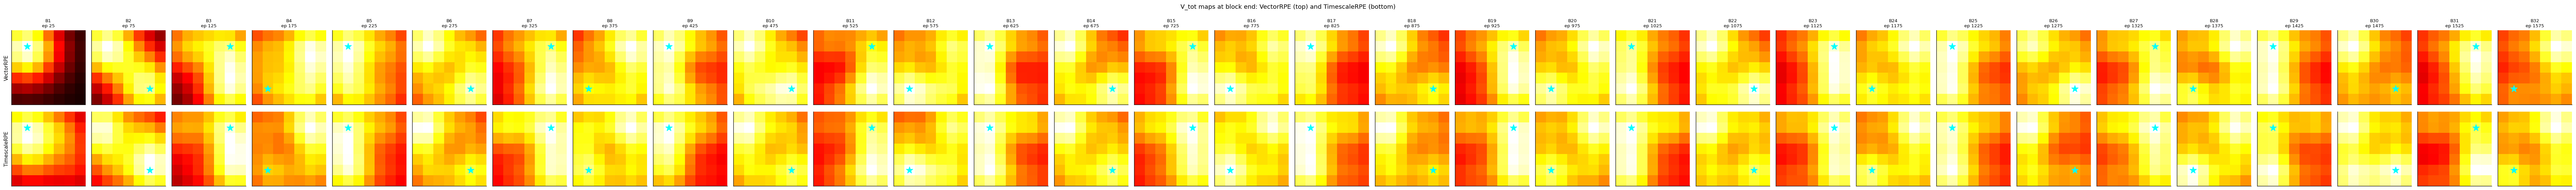

In [165]:
fig,axes=plt.subplots(2,N_BLOCKS,figsize=(2*N_BLOCKS,5))
fig.suptitle('V_tot maps at block end: VectorRPE (top) and TimescaleRPE (bottom)',fontsize=11)
for blk in range(N_BLOCKS):
    ci=ckpts_in_block(blk)[-1]; gr,gc=block_goals[blk]
    for row,name in enumerate(['VectorRPE','TimescaleRPE']):
        ax=axes[row,blk]
        im=ax.imshow(arr(f'{name}__val_maps')[ci],cmap='hot',origin='upper',vmin=0)
        ax.scatter([gc],[gr],marker='*',s=150,c='cyan',zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if blk==0: ax.set_ylabel(name,fontsize=9)
        if row==0: ax.set_title(f'B{blk+1}\nep {checkpoints[ci]}',fontsize=8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig11_weight_maps.pdf',bbox_inches='tight'); plt.show()

## 12  TimescaleRPE: β_i vs V_i(s) per channel

For each of the N_VALUES channels: scatter plot of V_i(s) at every grid cell,
coloured by distance to the goal that channel is meant to predict.
β_i determines how much that channel's value prediction contributes to V_tot.

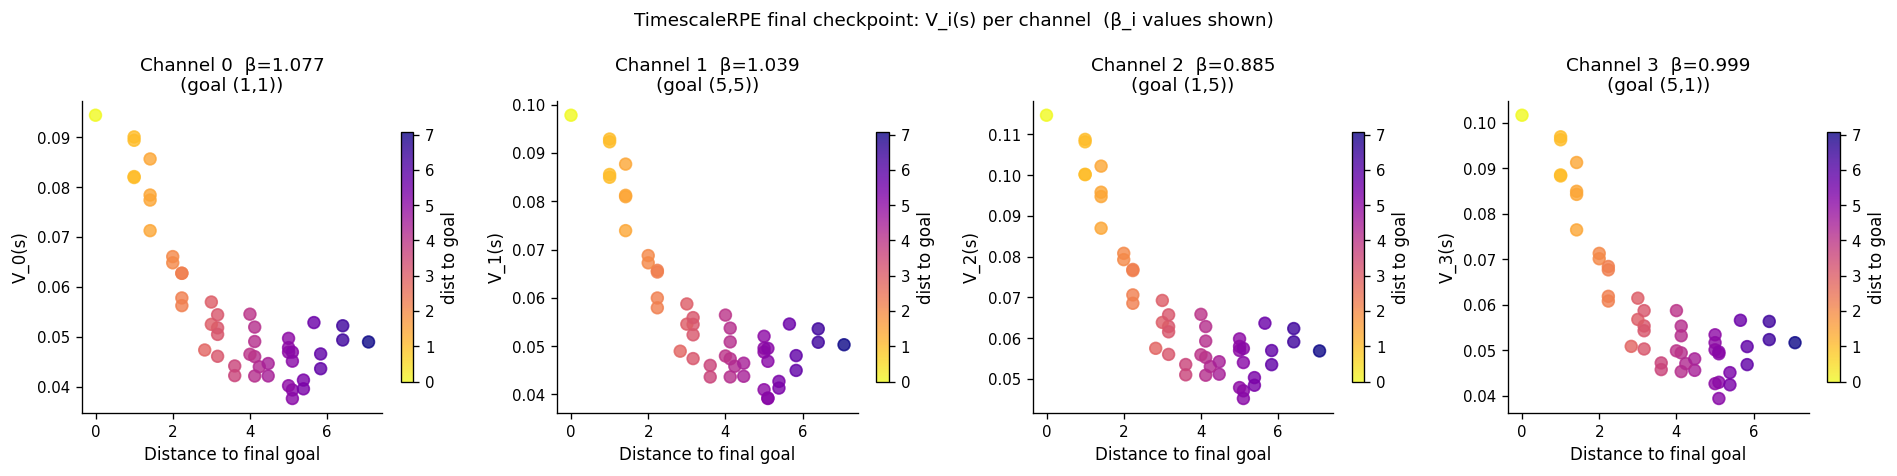

In [166]:
ci_f=len(checkpoints)-1
gr_f,gc_f=block_goals[-1]
dists=np.array([np.sqrt((r-gr_f)**2+(c-gc_f)**2) for r in range(H) for c in range(W)])
chan_v_final=arr('TimescaleRPE__chan_val_maps')[ci_f]  # (N_VALUES, H, W)
beta_final=arr('TimescaleRPE__beta_history')[-1]      # (N_VALUES,)

fig,axes=plt.subplots(1,N_VALUES,figsize=(4*N_VALUES,4))
fig.suptitle(f'TimescaleRPE final checkpoint: V_i(s) per channel  (β_i values shown)',fontsize=11)
for ch in range(N_VALUES):
    ax=axes[ch] if N_VALUES>1 else axes
    vi=chan_v_final[ch].ravel()
    sc=ax.scatter(dists,vi,c=dists,cmap='plasma_r',alpha=0.8,s=50)
    ax.set_xlabel('Distance to final goal'); ax.set_ylabel(f'V_{ch}(s)')
    ax.set_title(f'Channel {ch}  β={beta_final[ch]:.3f}\n(goal ({unique_goals[ch][0]},{unique_goals[ch][1]}))')
    plt.colorbar(sc,ax=ax,label='dist to goal',shrink=0.8)
plt.tight_layout(); plt.savefig('./data/gridworld/fig12_channel_vs_dist.pdf',bbox_inches='tight'); plt.show()

## 13  Decomposition verification:  $\sum_i \beta_i V_i(s) = V_{\text{total}}(s) \approx r$

The model guarantees $V_{\text{total}} = \sum_i \beta_i V_i$ by construction.
These plots confirm it holds numerically and show how each channel contributes.

At convergence near the goal, $V_{\text{total}}(s_{\text{goal}}) \approx r = 1$
and $V_{\text{total}}(s) \approx \gamma^{d(s, \text{goal})}$ where $d$ is the
 optimal path length.

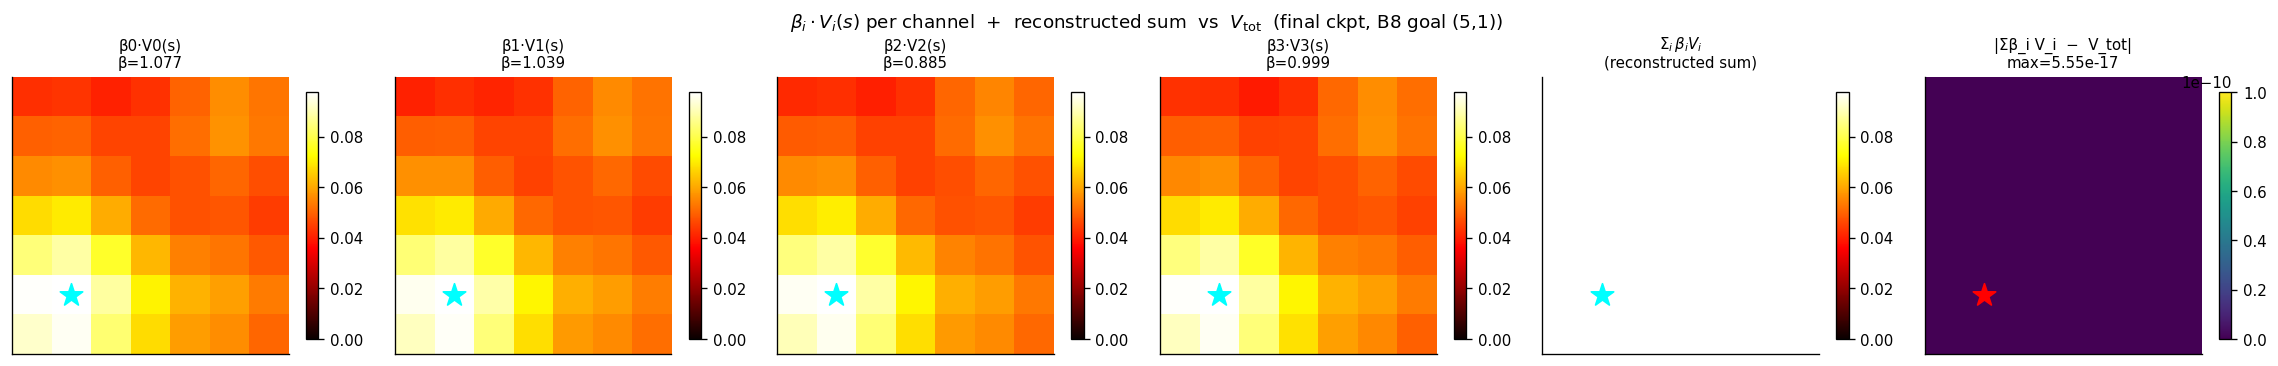

Max reconstruction error: 5.551e-17  (should be < 1e-12 by construction)


In [167]:
# ── Setup: load channel data at the last checkpoint of the final block ──────
ci_final = len(checkpoints) - 1
chan_v    = arr('TimescaleRPE__chan_val_maps')[ci_final]   # (N_VALUES, H, W)
beta_f    = arr('TimescaleRPE__beta_history')[ci_final]   # (N_VALUES,)
vtot_map  = arr('TimescaleRPE__val_maps')[ci_final]       # (H, W)  from agent.val()
gr_f, gc_f = int(block_goals[-1][0]), int(block_goals[-1][1])

# Weighted contributions β_i * V_i(s)  — one (H,W) map per channel
weighted  = np.array([beta_f[i] * chan_v[i] for i in range(N_VALUES)])  # (N_VALUES, H, W)
recon_sum = weighted.sum(axis=0)       # Σ_i β_i V_i(s)  — should equal vtot_map
diff_map  = recon_sum - vtot_map       # numerical error — should be ~0

n_cols = N_VALUES + 2   # one col per channel + sum + difference
fig, axes = plt.subplots(1, n_cols, figsize=(3.2 * n_cols, 3.2))
fig.suptitle(
    r'$\beta_i \cdot V_i(s)$ per channel  +  reconstructed sum  vs  $V_{\mathrm{tot}}$'
    f'  (final ckpt, B8 goal ({gr_f},{gc_f}))', fontsize=11)

# Per-channel weighted maps
vmax = np.percentile(np.abs(weighted), 98)
for ch in range(N_VALUES):
    ax = axes[ch]
    im = ax.imshow(weighted[ch], cmap='hot', origin='upper', vmin=0, vmax=vmax)
    ax.scatter([gc_f], [gr_f], marker='*', s=200, c='cyan', zorder=5)
    ax.set_title(f'β{ch}·V{ch}(s)\nβ={beta_f[ch]:.3f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)

# Reconstructed sum  Σ β_i V_i
ax = axes[N_VALUES]
im = ax.imshow(recon_sum, cmap='hot', origin='upper', vmin=0, vmax=vmax)
ax.scatter([gc_f], [gr_f], marker='*', s=200, c='cyan', zorder=5)
ax.set_title(r'$\Sigma_i\,\beta_i V_i$' + f'\n(reconstructed sum)', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, shrink=0.8)

# Difference  Σ β_i V_i  −  V_total  (should be ~0 everywhere)
ax = axes[N_VALUES + 1]
d_abs = np.abs(diff_map)
im = ax.imshow(d_abs, cmap='viridis', origin='upper',
               vmin=0, vmax=max(d_abs.max(), 1e-10))
ax.scatter([gc_f], [gr_f], marker='*', s=200, c='red', zorder=5)
ax.set_title(f'|Σβ_i V_i  −  V_tot|\nmax={d_abs.max():.2e}', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig13a_decomposition_maps.pdf', bbox_inches='tight')
plt.show()

print(f'Max reconstruction error: {d_abs.max():.3e}  (should be < 1e-12 by construction)')

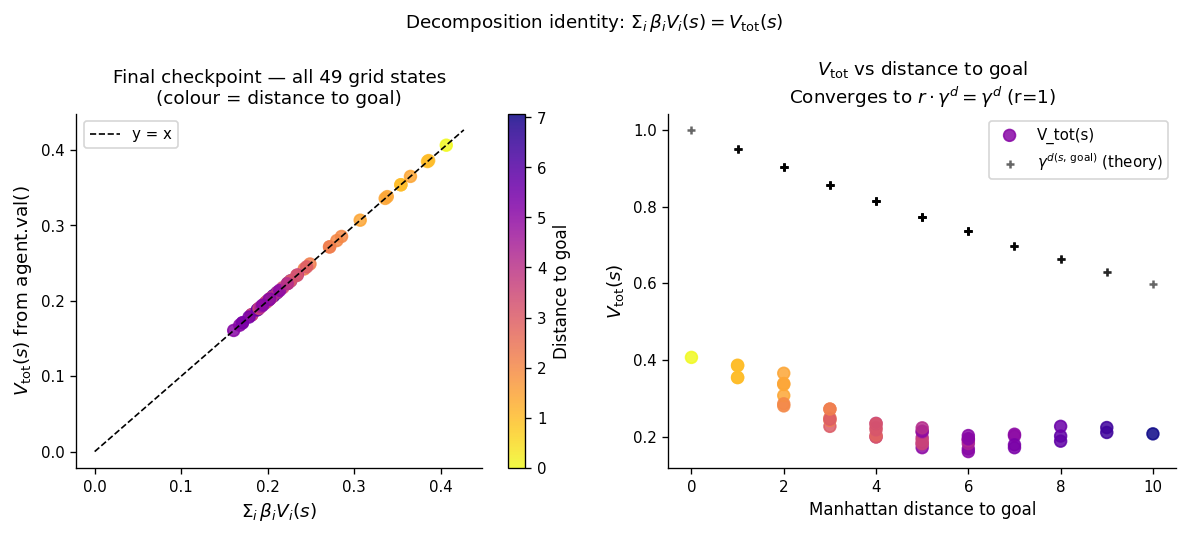

In [168]:
# Every grid state as one point — if the identity holds exactly, all points
# lie on the diagonal y = x.

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle(r'Decomposition identity: $\Sigma_i\,\beta_i V_i(s) = V_{\mathrm{tot}}(s)$',
             fontsize=11)

# Left: scatter at final checkpoint
ax = axes[0]
xs = recon_sum.ravel()   # Σ β_i V_i  (x)
ys = vtot_map.ravel()    # V_tot from agent.val()  (y)
dists = np.array([np.sqrt((r-gr_f)**2+(c-gc_f)**2)
                  for r in range(H) for c in range(W)])
sc = ax.scatter(xs, ys, c=dists, cmap='plasma_r', s=50, alpha=0.85)
lim = max(xs.max(), ys.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='y = x')
ax.set_xlabel(r'$\Sigma_i\,\beta_i V_i(s)$', fontsize=11)
ax.set_ylabel(r'$V_{\mathrm{tot}}(s)$ from agent.val()', fontsize=11)
ax.set_title('Final checkpoint — all 49 grid states\n(colour = distance to goal)')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Distance to goal')

# Right: V_total vs discounted distance  γ^k  (theoretical value at k steps from goal)
ax = axes[1]
# Compute optimal Manhattan distance (shortest path) to current goal
man_dist = np.array([abs(r-gr_f)+abs(c-gc_f) for r in range(H) for c in range(W)])
theory   = float(arr('GAMMA_RPE')) ** man_dist   # γ^d   — theoretical lower bound on V*
ax.scatter(man_dist, vtot_map.ravel(), c=dists, cmap='plasma_r',
           s=50, alpha=0.85, label='V_tot(s)')
ax.scatter(man_dist, theory, c='black', s=20, marker='+',
           alpha=0.6, label=r'$\gamma^{d(s,\,\mathrm{goal})}$ (theory)')
ax.set_xlabel('Manhattan distance to goal', fontsize=10)
ax.set_ylabel(r'$V_{\mathrm{tot}}(s)$', fontsize=11)
ax.set_title(r'$V_{\mathrm{tot}}$ vs distance to goal' + '\n'
             r'Converges to $r\cdot\gamma^d = \gamma^d$ (r=1)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./data/gridworld/fig13b_decomp_scatter.pdf', bbox_inches='tight')
plt.show()

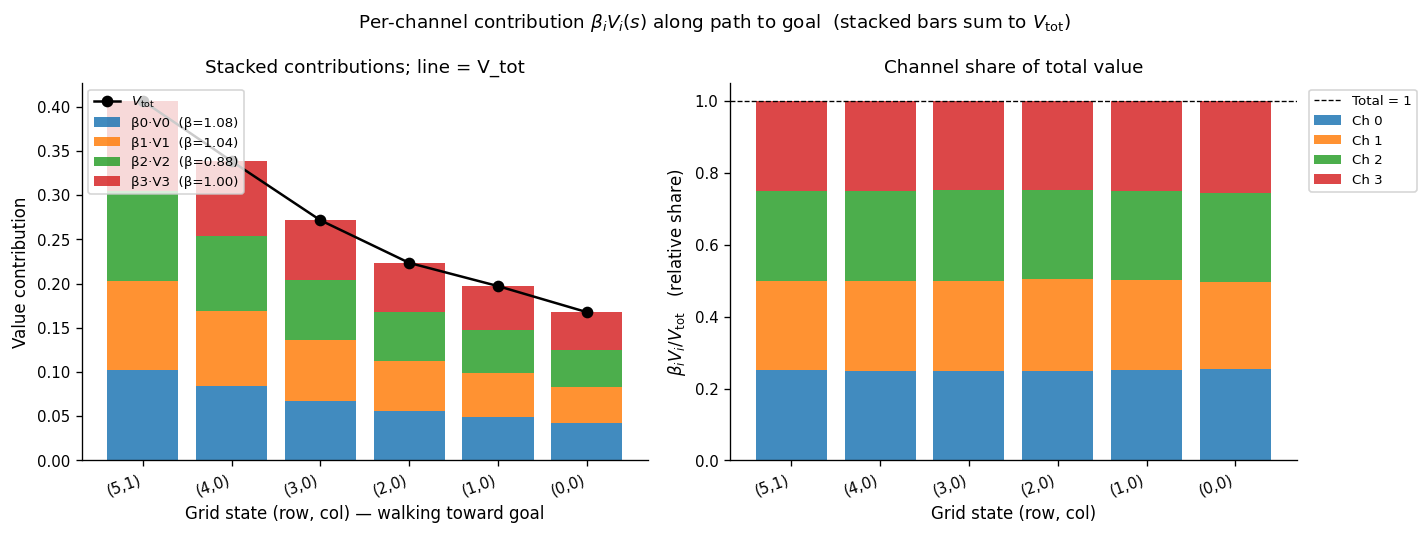

In [169]:
# For a handful of states along the optimal path to the goal,
# show a stacked bar where each segment = β_i V_i  (contribution of channel i).
# The total bar height = V_total  — should match the scalar value line.

# Pick ~6 states along the diagonal from top-left to goal
selected_states = []
for step in range(max(H, W)):
    r = max(0, gr_f - step)
    c = max(0, gc_f - step)
    idx = int(r) * W + int(c)
    if idx not in selected_states:
        selected_states.append(idx)
selected_states = selected_states[:8]   # keep at most 8

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(r'Per-channel contribution $\beta_i V_i(s)$ along path to goal  '
             '(stacked bars sum to $V_{\mathrm{tot}}$)', fontsize=11)

chan_colors = [f'C{i}' for i in range(N_VALUES)]

# Left: stacked bars — contributions at each selected state
ax = axes[0]
x = np.arange(len(selected_states))
bottoms = np.zeros(len(selected_states))
for ch in range(N_VALUES):
    contrib = np.array([beta_f[ch] * chan_v[ch].ravel()[s] for s in selected_states])
    ax.bar(x, contrib, bottom=bottoms, color=chan_colors[ch],
           alpha=0.85, label=f'β{ch}·V{ch}  (β={beta_f[ch]:.2f})')
    bottoms += contrib

# Overlay V_total as a line
vtot_sel = [vtot_map.ravel()[s] for s in selected_states]
ax.plot(x, vtot_sel, 'k-o', lw=1.5, ms=6, zorder=5, label=r'$V_{\mathrm{tot}}$')

xlbls = [f'({s//W},{s%W})' for s in selected_states]
ax.set_xticks(x)
ax.set_xticklabels(xlbls, rotation=20, ha='right')
ax.set_xlabel('Grid state (row, col) — walking toward goal')
ax.set_ylabel('Value contribution')
ax.set_title('Stacked contributions; line = V_tot')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(0, color='k', lw=0.5)

# Right: relative share of each channel  β_i V_i / V_tot  (normalised stacked bar)
ax = axes[1]
bottoms = np.zeros(len(selected_states))
for ch in range(N_VALUES):
    contrib = np.array([beta_f[ch] * chan_v[ch].ravel()[s] for s in selected_states])
    share   = np.where(np.abs(vtot_sel) > 1e-8,
                       contrib / np.array(vtot_sel), 0)
    ax.bar(x, share, bottom=bottoms, color=chan_colors[ch],
           alpha=0.85, label=f'Ch {ch}')
    bottoms += share

ax.axhline(1.0, color='k', lw=0.8, ls='--', label='Total = 1')
ax.set_xticks(x)
ax.set_xticklabels(xlbls, rotation=20, ha='right')
ax.set_xlabel('Grid state (row, col)')
ax.set_ylabel(r'$\beta_i V_i / V_{\mathrm{tot}}$   (relative share)')
ax.set_title('Channel share of total value')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('./data/gridworld/fig13c_contribution_bars.pdf', bbox_inches='tight')
plt.show()

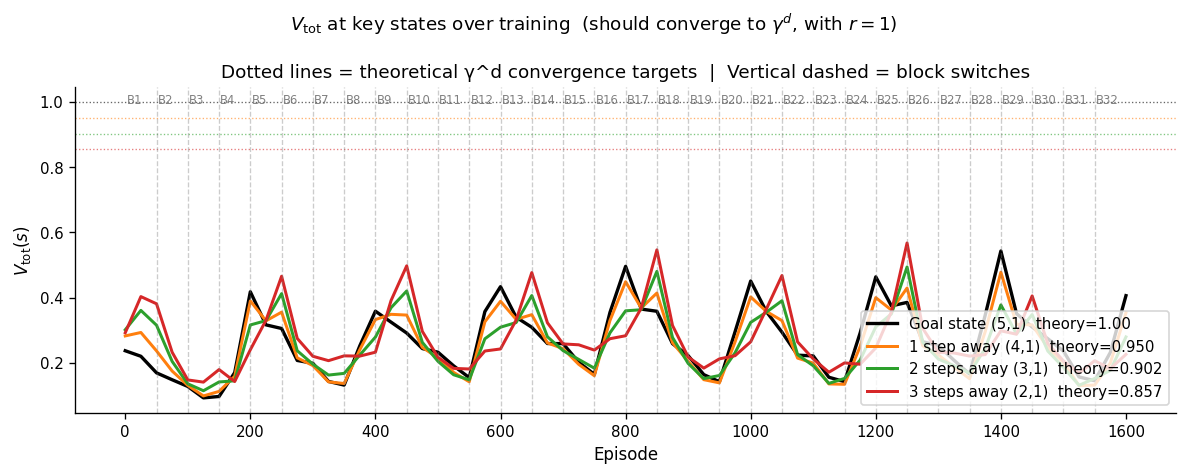

In [170]:
# Track how V_total at the goal state evolves across training checkpoints.
# It should rise from 0 toward r=1 as learning progresses.
# Also show V_total at states 1, 2, 3 steps from goal → should converge to γ, γ², γ³.

goal_state = gr_f * W + gc_f

# States at 1 and 2 Manhattan steps from goal (pick the first we find)
def find_state_at_dist(goal_r, goal_c, manhattan_d):
    for r in range(H):
        for c in range(W):
            if abs(r - goal_r) + abs(c - goal_c) == manhattan_d:
                return r * W + c
    return None

s1 = find_state_at_dist(gr_f, gc_f, 1)
s2 = find_state_at_dist(gr_f, gc_f, 2)
s3 = find_state_at_dist(gr_f, gc_f, 3)
gamma = float(arr('GAMMA_RPE'))

all_vmaps = arr('TimescaleRPE__val_maps')   # (N_ckpts, H, W)

v_goal = all_vmaps[:, gr_f, gc_f]
v_1    = all_vmaps[:, s1 // W, s1 % W] if s1 is not None else None
v_2    = all_vmaps[:, s2 // W, s2 % W] if s2 is not None else None
v_3    = all_vmaps[:, s3 // W, s3 % W] if s3 is not None else None

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(r'$V_{\mathrm{tot}}$ at key states over training  '
             r'(should converge to $\gamma^d$, with $r=1$)', fontsize=11)

ax.plot(checkpoints, v_goal, lw=2, color='black',
        label=f'Goal state ({gr_f},{gc_f})  theory=1.00')
ax.axhline(1.0,   color='black', lw=0.8, ls=':', alpha=0.6)
if v_1 is not None:
    r1, c1 = s1 // W, s1 % W
    ax.plot(checkpoints, v_1, lw=1.8, color='C1',
            label=f'1 step away ({r1},{c1})  theory={gamma:.3f}')
    ax.axhline(gamma,    color='C1', lw=0.8, ls=':', alpha=0.6)
if v_2 is not None:
    r2, c2 = s2 // W, s2 % W
    ax.plot(checkpoints, v_2, lw=1.8, color='C2',
            label=f'2 steps away ({r2},{c2})  theory={gamma**2:.3f}')
    ax.axhline(gamma**2, color='C2', lw=0.8, ls=':', alpha=0.6)
if v_3 is not None:
    r3, c3 = s3 // W, s3 % W
    ax.plot(checkpoints, v_3, lw=1.8, color='C3',
            label=f'3 steps away ({r3},{c3})  theory={gamma**3:.3f}')
    ax.axhline(gamma**3, color='C3', lw=0.8, ls=':', alpha=0.6)

# Mark block boundaries
for be in block_eps[1:]:
    ax.axvline(be, color='gray', lw=0.8, ls='--', alpha=0.4)
for i, be in enumerate(block_eps):
    ax.text(be + 2, ax.get_ylim()[1] * 0.98 if ax.get_ylim()[1] > 0 else 0.05,
            f'B{i+1}', fontsize=7, color='gray', va='top')

ax.set_xlabel('Episode')
ax.set_ylabel(r'$V_{\mathrm{tot}}(s)$')
ax.set_title('Dotted lines = theoretical γ^d convergence targets  |  '
             'Vertical dashed = block switches')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('./data/gridworld/fig13d_vtot_convergence.pdf', bbox_inches='tight')
plt.show()

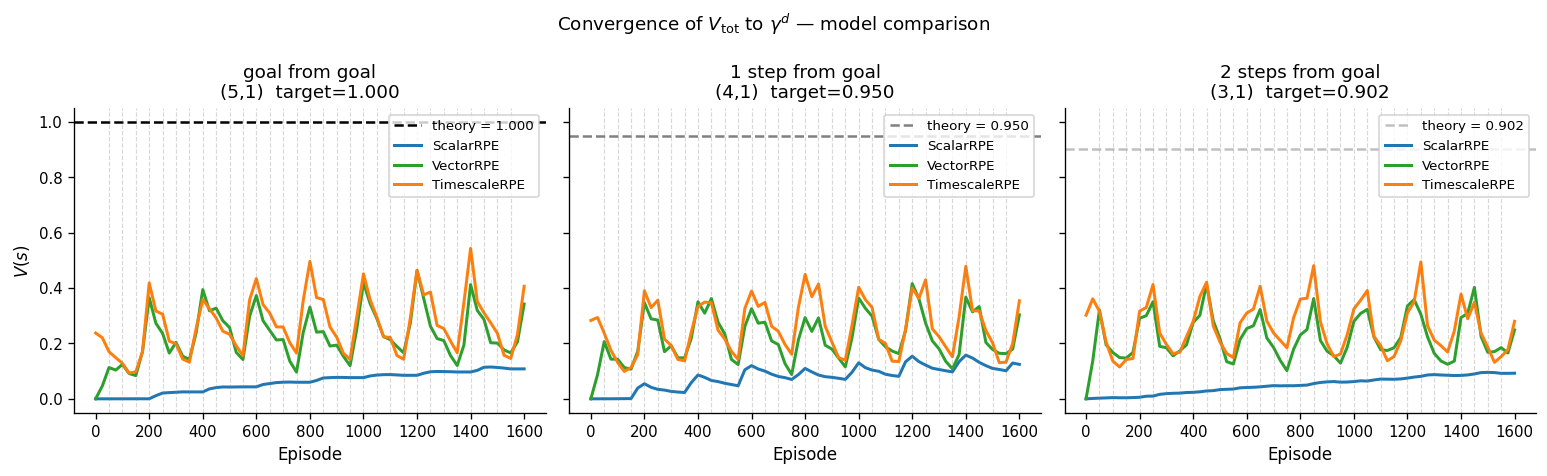

In [171]:
# Compare how quickly VectorRPE, TimescaleRPE, and ScalarRPE converge
# to the theoretical value at the goal and at 1-2 steps away.

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle(r'Convergence of $V_{\mathrm{tot}}$ to $\gamma^d$ — model comparison', fontsize=11)

model_styles = {
    'ScalarRPE':    dict(color='#1f77b4', lw=1.8),
    'VectorRPE':    dict(color='#2ca02c', lw=1.8),
    'TimescaleRPE': dict(color='#ff7f0e', lw=1.8),
}
targets = [
    (goal_state, 1.0,      'goal', 'black'),
    (s1,         gamma,    '1 step', 'gray'),
    (s2,         gamma**2, '2 steps', 'silver'),
]

for col, (state_idx, theory, dist_label, tcolor) in enumerate(targets):
    ax = axes[col]
    if state_idx is None:
        ax.set_visible(False); continue
    sr, sc_ = state_idx // W, state_idx % W
    ax.axhline(theory, color=tcolor, lw=1.5, ls='--',
               label=f'theory = {theory:.3f}')
    for name, style in model_styles.items():
        vmaps = arr(f'{name}__val_maps')  # (N_ckpts, H, W)
        ax.plot(checkpoints, vmaps[:, sr, sc_], label=name, **style)
    for be in block_eps[1:]:
        ax.axvline(be, color='gray', lw=0.7, ls='--', alpha=0.3)
    ax.set_title(f'{dist_label} from goal\n({sr},{sc_})  target={theory:.3f}')
    ax.set_xlabel('Episode')
    if col == 0:
        ax.set_ylabel(r'$V(s)$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig13e_model_convergence.pdf', bbox_inches='tight')
plt.show()